![display relevant image here](https://images.openai.com/static-rsc-4/6bi6gMJ3pIealGwI30v-OEk3qRIdq_JJaTL4lqSrhapzBiFmcP3XKMGNMcZt2scxhraQ5K47UFzuIgpDV5617vQ3PmrcWmMMOgeg87yT14pxWGOBivIJmrTXpXjddLGxTHIii584hNg8spjgxzoO7FEXNpomNBA0Q8u89qJDZTUISUi_Wc2ggp_fzkbewXEs?purpose=fullsize)


# Loan Approval Prediction Using Machine Learning

**Author:** Francis Wairagu  
**Project Type:** Supervised Machine Learning (Binary Classification)  
**Methodology:** CRISP-DM  
**Dataset:** Financial Risk for Loan Approval (20,000 loan applications)  
**Target Variable:** `LoanApproved`  
**Final Model:** Logistic Regression  
**Primary Business Objective:** Support reliable, data-driven loan approval decisions while minimizing lending risk.

## Financial Loan Risk

Financial institutions face the challenge of balancing profitable lending with effective risk management. Approving loans for applicants who are unlikely to repay can lead to financial losses, while rejecting creditworthy applicants may reduce customer satisfaction and business growth. Leveraging historical applicant data and machine learning enables lenders to make faster, more consistent, and data-driven loan approval decisions. This project explores how applicant financial, demographic, and credit characteristics can be used to predict loan approval and support better lending decisions.


## Overview

### **BLUF (Bottom Line Up Front)**

An end-to-end machine learning solution developed to predict loan approval using applicants' financial, demographic, and credit information. After evaluating five classification models, **Logistic Regression** achieved the best overall performance, with **93% accuracy**, **88% precision**, **85% recall**, and an **F1-score of 86%**, making it the selected model for this project.

### **Summary**

This project follows the CRISP-DM methodology to build a loan approval prediction model using a dataset of 20,000 loan applications. The workflow includes data cleaning, exploratory data analysis, feature engineering, model benchmarking, and evaluation. The analysis identified **Total Debt-to-Income Ratio, Monthly Income, Loan Duration, and Net Worth** as the most influential factors in loan approval decisions, demonstrating how machine learning can support more consistent and data-driven lending decisions while reducing financial risk.


## Business Understanding

Financial institutions process thousands of loan applications every year. Assessing whether an applicant should receive a loan is a critical task that directly affects profitability and financial stability. Traditionally, loan officers evaluate applications using an applicant's financial profile, employment history, creditworthiness, and other relevant factors.

As the volume of applications grows, manual decision-making becomes increasingly time-consuming and may lead to inconsistent evaluations. Machine learning offers an opportunity to support this process by identifying patterns in historical applicant data and predicting whether a loan should be approved.


## Business Problem

Loan approval decisions involve balancing two competing objectives:
- Approving creditworthy applicants to maximize revenue.
- Rejecting high-risk applicants to minimize potential financial losses.

Incorrect decisions can have significant consequences. Approving a high-risk applicant may increase the likelihood of loan default, while rejecting a qualified applicant represents a missed business opportunity and may negatively impact customer satisfaction.

This project aims to build a predictive model that assists financial institutions in making consistent, data-driven loan approval decisions.

## Business Objectives

The project aims to:
- Predict whether a loan application should be approved.
- Identify the factors that most influence loan approval.
- Reduce the time required to evaluate loan applications.
- Support consistent and objective lending decisions.

## Stakeholders

The results of this project would be valuable to several stakeholders, including:
- Loan officers responsible for reviewing applications.
- Credit risk analysts who assess applicant risk.
- Bank management seeking to improve lending efficiency.
- Customers who benefit from faster and more consistent decisions.

## Success Criteria

From a business perspective, the project is successful if the model can support faster and more consistent loan approval decisions while minimizing risky approvals.

From a machine learning perspective, success will be evaluated using metrics such as:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Given the financial context, particular attention will be paid to balancing false approvals and false rejections.

## Data Understanding


In [213]:
# Imports
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier

warnings.filterwarnings(action="ignore")

### Initial Data Inspection
The purpose of this section is to gain an overview of the dataset before performing any cleaning or analysis. We will examine the structure, dimensions, data types, and overall quality of the data to identify any issues that require attention.

In [166]:
# EDA Code Here - Create New Cells As Needed
# load the data 
df = pd.read_csv("financial_loan_data.csv")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 20000
Columns: 35


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [167]:
# Get dataset information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [168]:
# summary statistics
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [169]:
# investigate the columns 
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='str')

### Dataset overview
Initial Observations (Markdown)

From the initial inspection, several points require further investigation:

- The dataset contains 20,000 observations and 35 variables.
- There are 28 numerical variables and 7 categorical variables.
- Two categorical variables (MaritalStatus and EducationLevel) contain missing values.
- One numerical (SavingsAccountBalance) variable also contains missing values.
- AnnualIncome is stored as a string instead of a numeric data type.
- Several variables appear to be closely related to the loan approval decision and may introduce target leakage if used during model training. e.g RiskScore

In [170]:
# Check for missing values 
missing = df.isna().sum().to_frame(name="Missing Values")
missing["percentage"] = round((missing["Missing Values"] / len(df)) * 100, 2)
missing = missing[missing["Missing Values"] > 0].sort_values("Missing Values", ascending=False)
missing

,Missing Values,percentage
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


In [171]:
# Check for duplicated rows 
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [172]:
# Examine target variable 
print(df.LoanApproved.value_counts())
# df.LoanApproved.value_counts(normalize=True) * 100

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


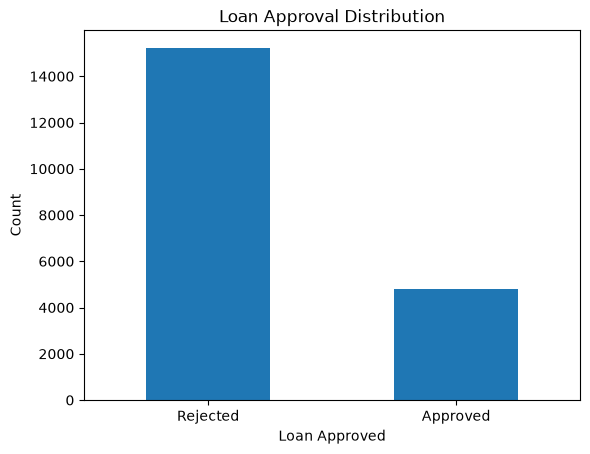

In [173]:
(
    df["LoanApproved"]
      .value_counts()
      .sort_index()
      .plot(kind="bar")
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.xticks([0, 1], ["Rejected", "Approved"], rotation=0)

plt.show()

In [174]:
# Investigate AnnualIncome column 
df.AnnualIncome.sample(5)

6031      $32,073.00
13500     $49,992.00
3969     $118,182.00
7031      $18,973.00
9227      $57,024.00
Name: AnnualIncome, dtype: str

### Potential Target Leakage
Some features may only be known after a loan has been approved. Including them in training would give the model information it wouldn't have at prediction time, resulting in unrealistically high performance.

Columns like Interest rate, Base interest rate, monthly loan payment, risk score, can only be known after the loan is approved

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



Missing saving account balance, it could mean:

- The customer has no savings account.
- The balance wasn't recorded.
- The data is missing at random.

In [175]:
# Inspect the column before filling 
df["SavingsAccountBalance"].describe()

count     19428.000000
mean       4949.148446
std        6628.404969
min          73.000000
25%        1542.000000
50%        2988.500000
75%        5869.250000
max      200089.000000
Name: SavingsAccountBalance, dtype: float64

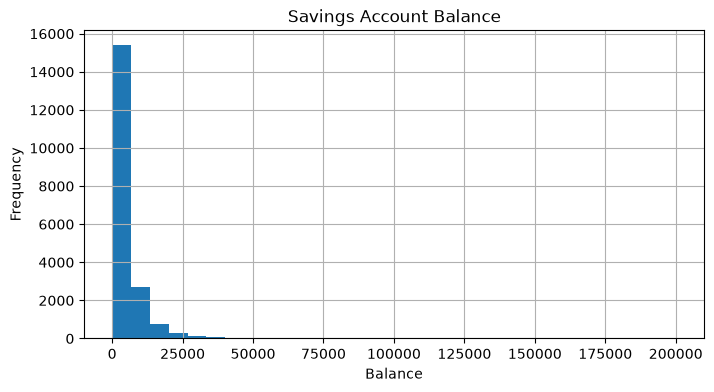

In [176]:
plt.figure(figsize=(8,4))

df["SavingsAccountBalance"].hist(bins=30)

plt.title("Savings Account Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

In [177]:
# Data Prep Code Here - Create New Cells As Needed
# convert annual income to float 

def cleaner(df):
    if df.AnnualIncome.dtype == "str":
        df.AnnualIncome = df.AnnualIncome.str.replace(r"[\$,]", "", regex=True).astype(float)

    # fill categorical values with unknown
    categorical_cols = ["MaritalStatus", "EducationLevel"]
    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")

    # fill the numerical with median 
    df['SavingsAccountBalance'] = df['SavingsAccountBalance'].fillna(df['SavingsAccountBalance'].median())    
    
    return df

In [178]:
# Run the dataframe through the cleaner function 
df = cleaner(df)

# verify missing values are gone 
df.isnull().sum().sort_values(ascending=False).head(5)

Age                 0
AnnualIncome        0
CreditScore         0
EmploymentStatus    0
EducationLevel      0
dtype: int64

<Axes: >

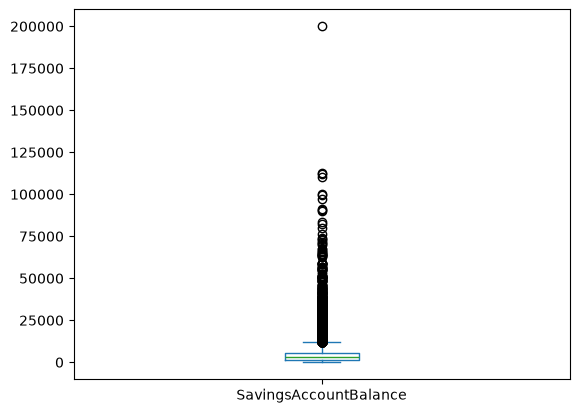

In [179]:
df["SavingsAccountBalance"].plot(kind="box")

## Exploratory Data Analysis (EDA)

### Univariate Analysis

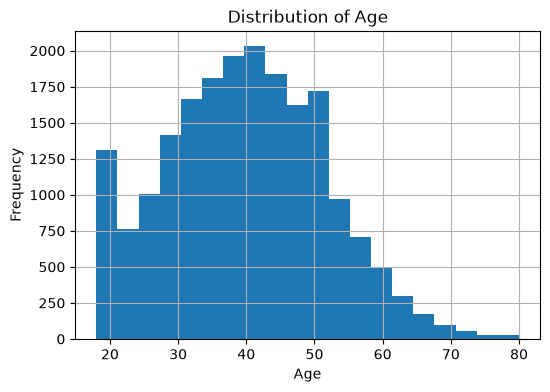

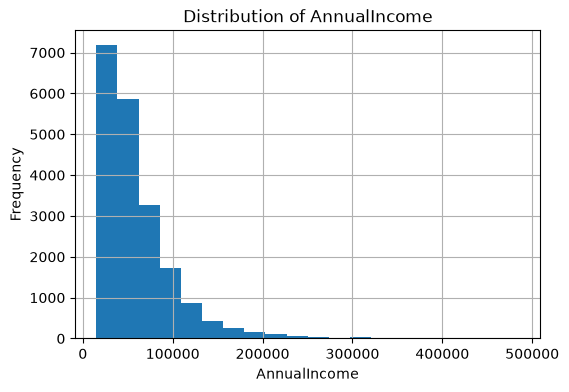

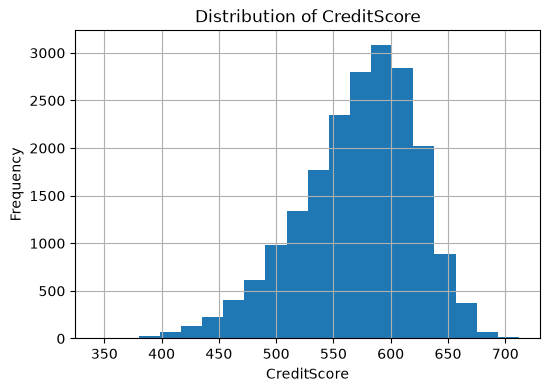

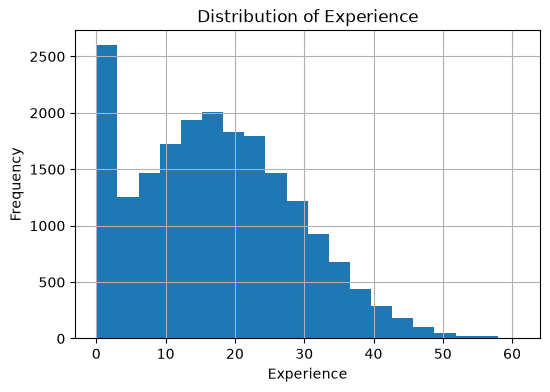

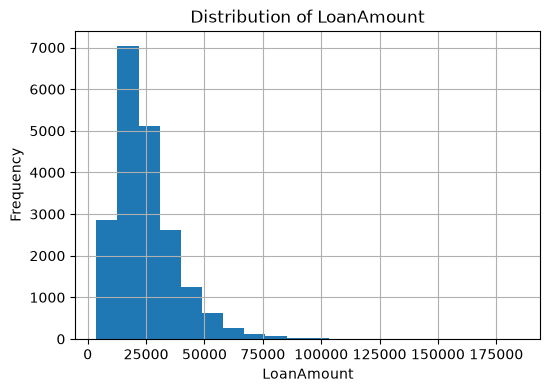

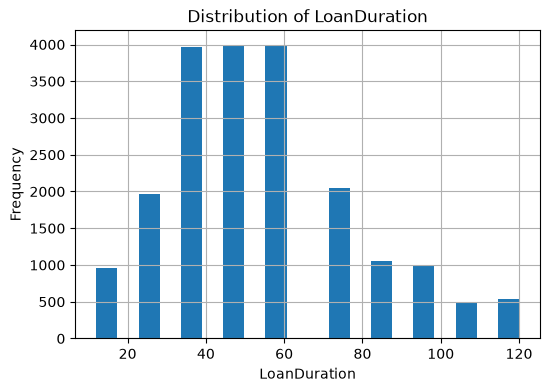

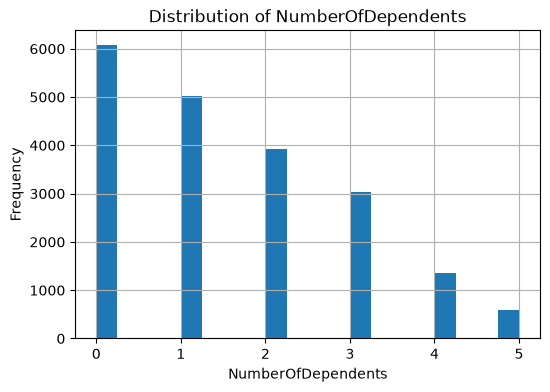

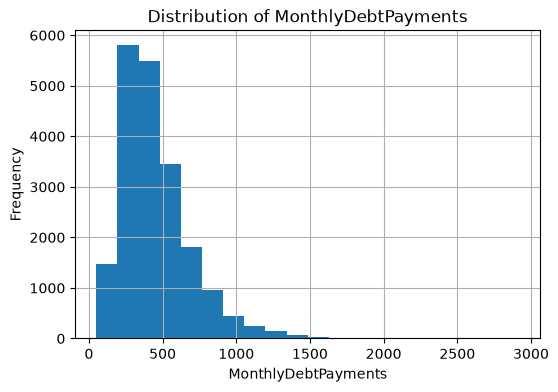

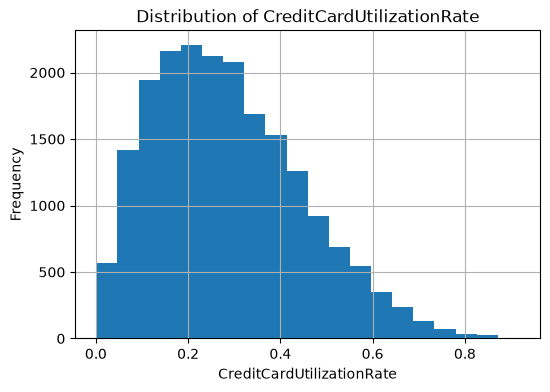

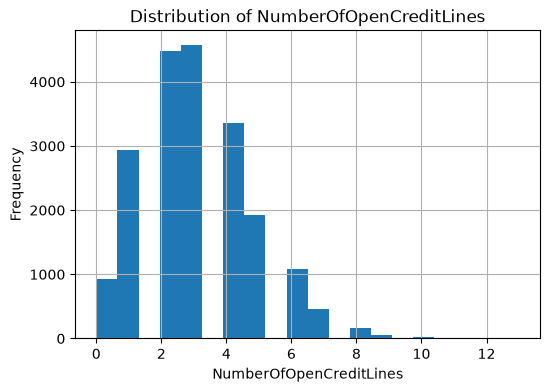

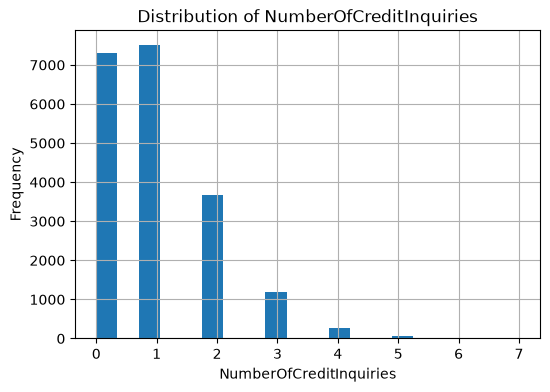

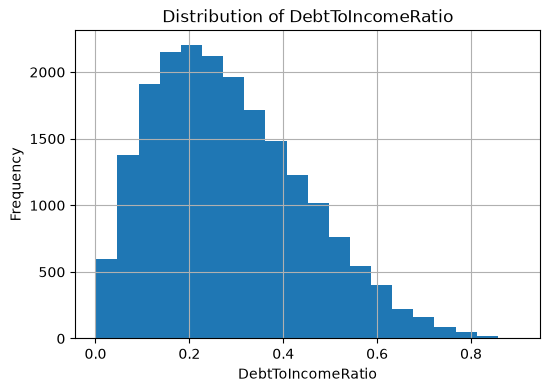

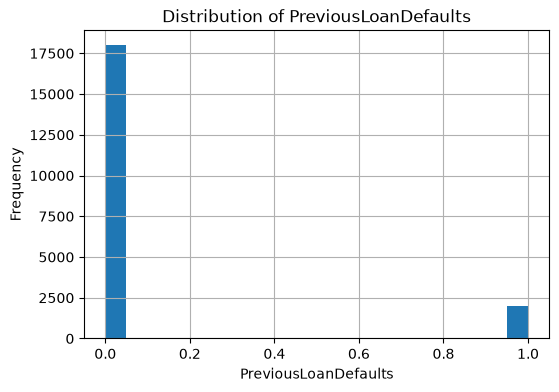

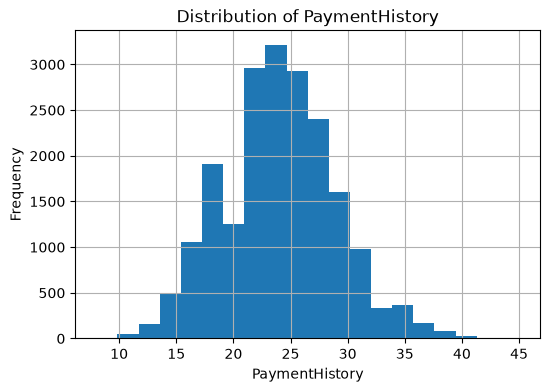

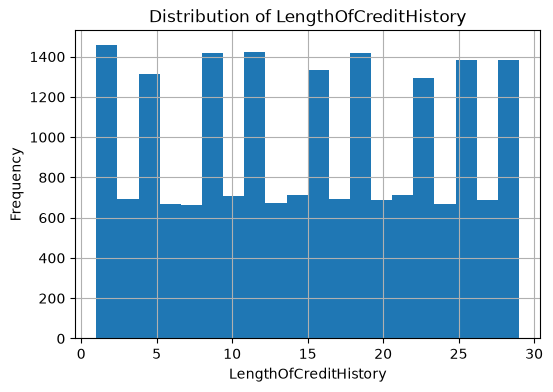

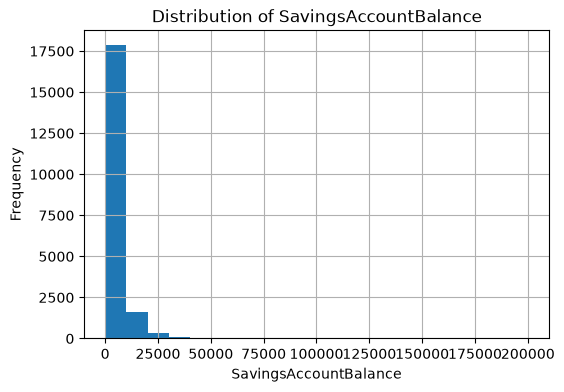

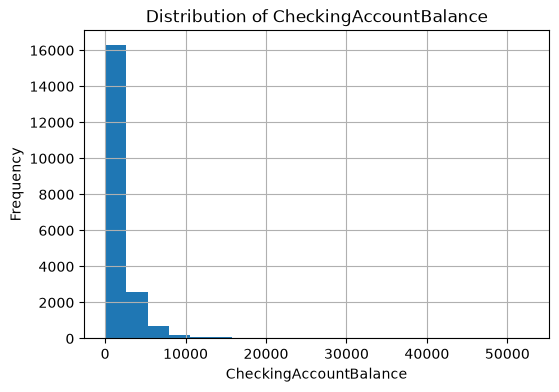

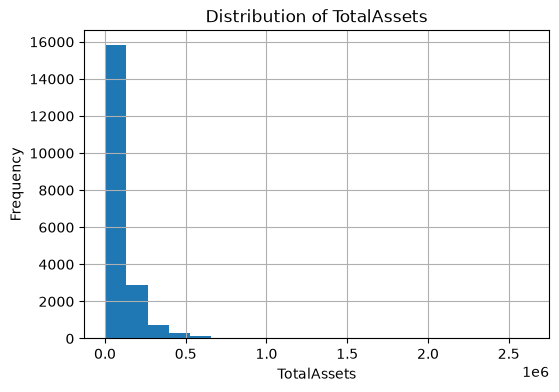

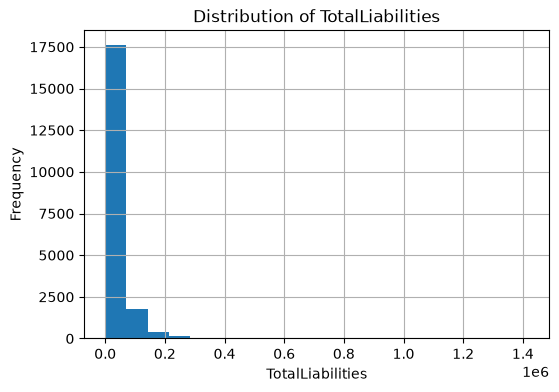

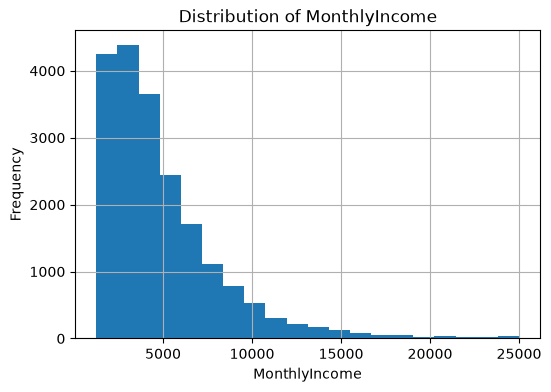

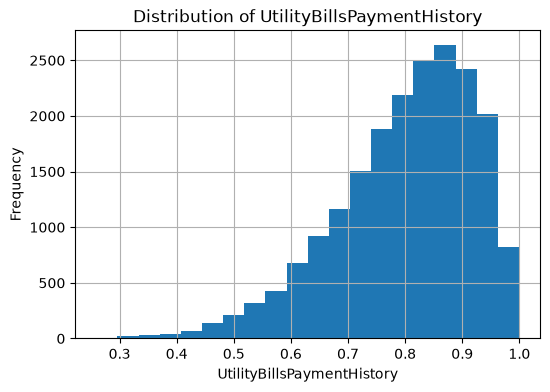

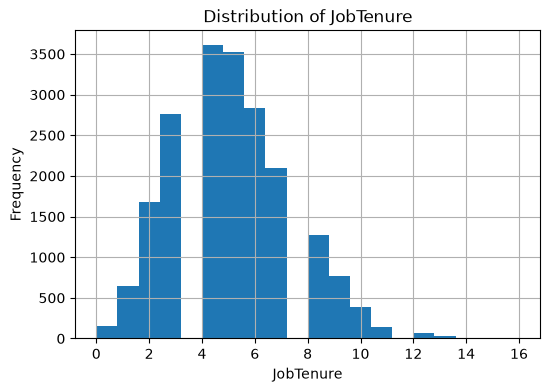

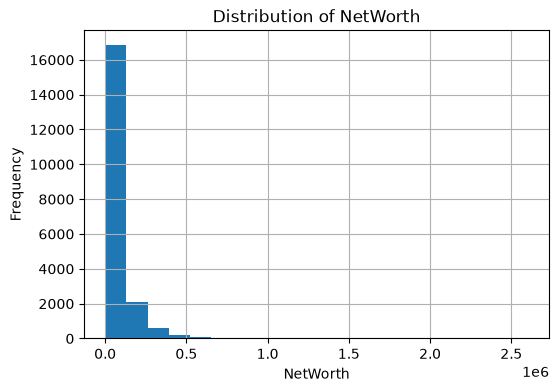

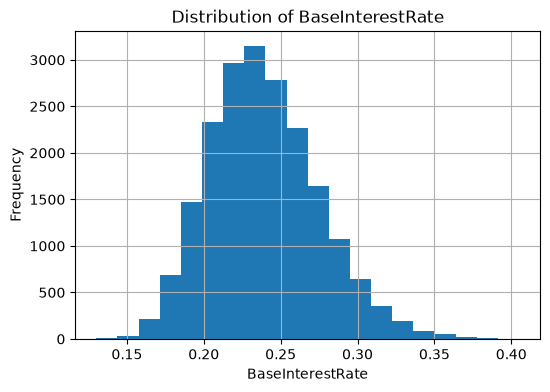

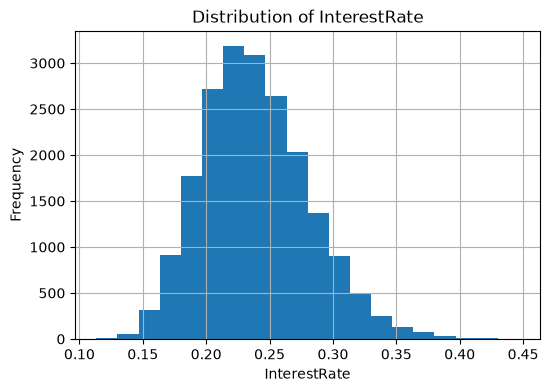

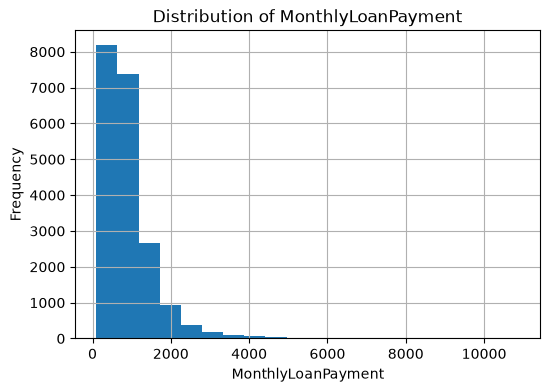

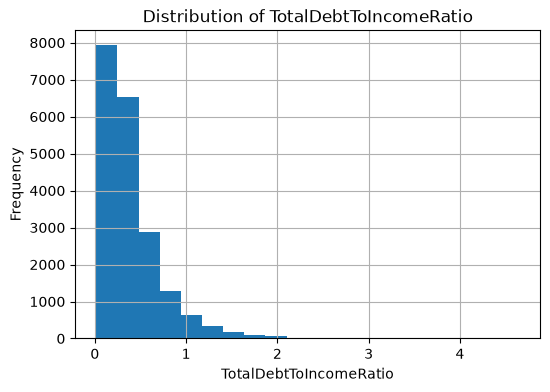

In [180]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(["LoanApproved", "RiskScore"])
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=20)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

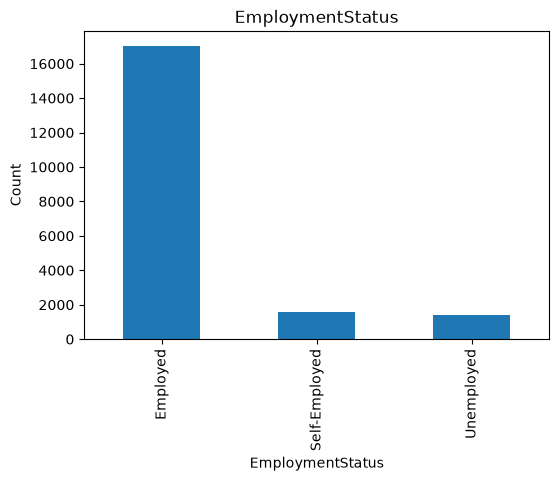

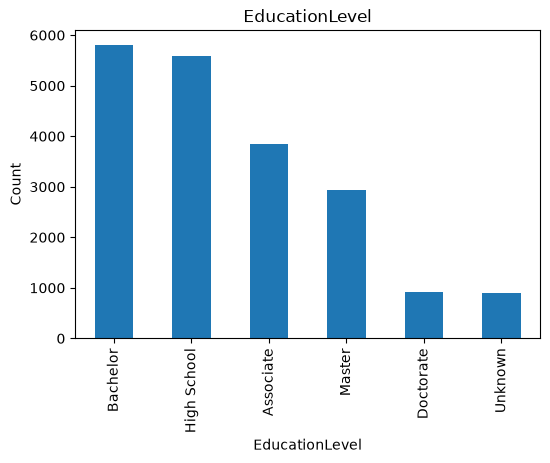

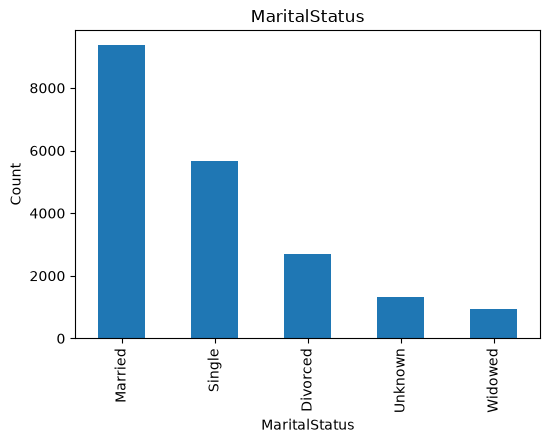

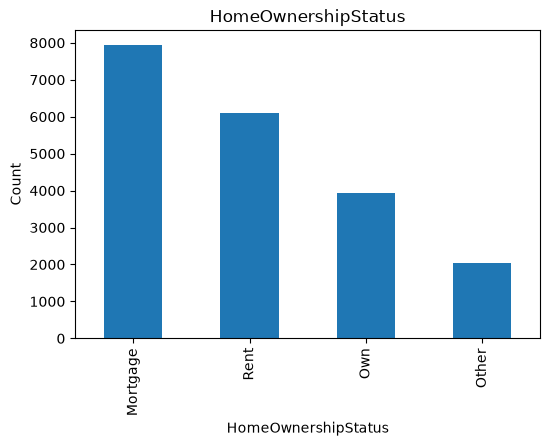

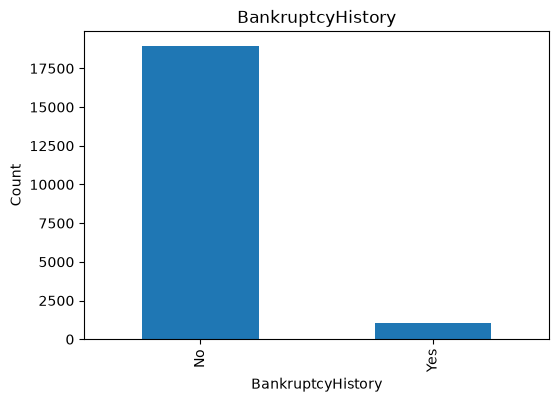

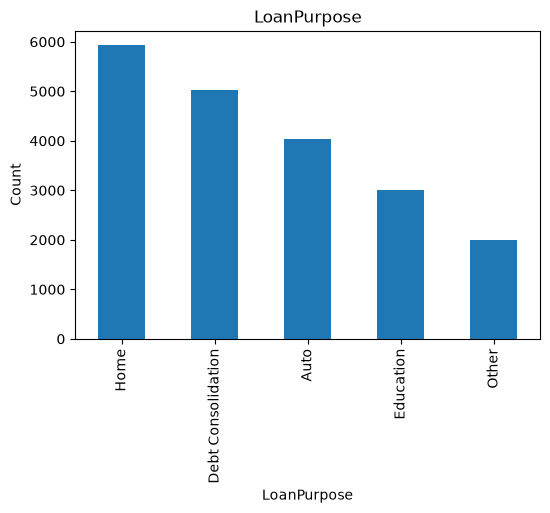

In [181]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.ylabel("Count")

    plt.show()

### Bivariate Analysis

#### 1. Does Credit score influence Loan Approval?

<Figure size 800x500 with 0 Axes>

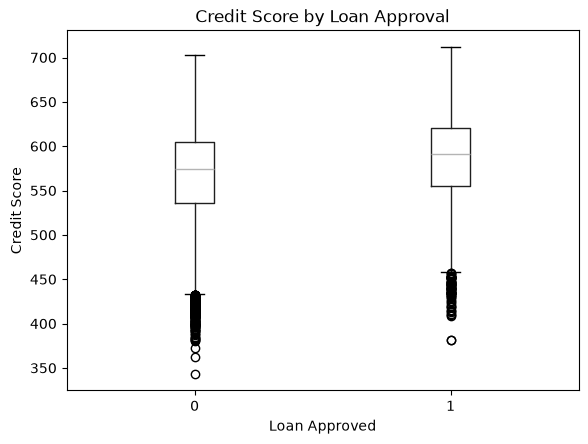

In [182]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="CreditScore",
    by="LoanApproved",
    grid=False
)

plt.title("Credit Score by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")

plt.show()

#### 2. Does annual income affect loan approval?

<Figure size 800x500 with 0 Axes>

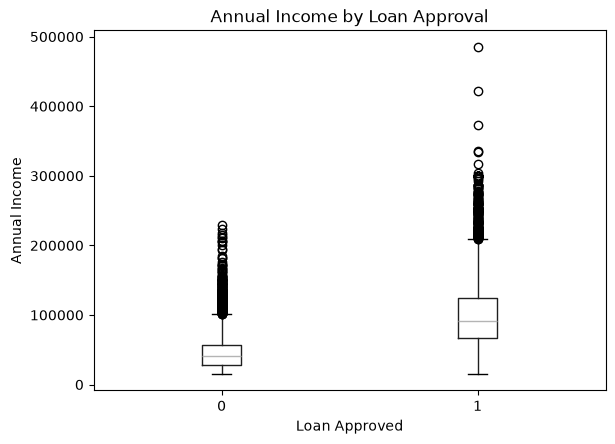

In [183]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="AnnualIncome",
    by="LoanApproved",
    grid=False
)

plt.title("Annual Income by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income")

plt.show()

#### 3. Does Dept-tp-income ratio affect approval?

<Figure size 800x500 with 0 Axes>

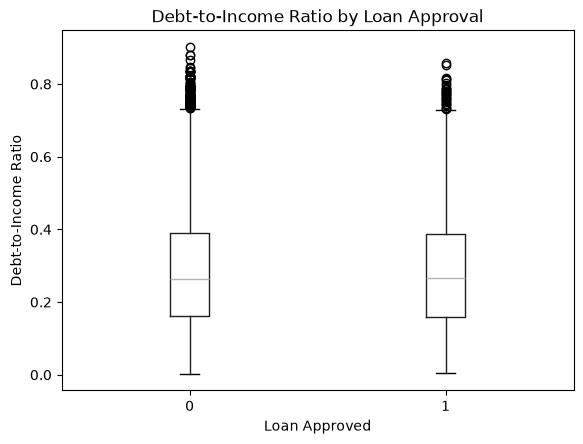

In [184]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="DebtToIncomeRatio",
    by="LoanApproved",
    grid=False
)

plt.title("Debt-to-Income Ratio by Loan Approval")
plt.suptitle("")
plt.xlabel("Loan Approved")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

#### 4. Does previous Loan default influence approval?

In [185]:
approval_rate = pd.crosstab(
    df["PreviousLoanDefaults"],
    df["LoanApproved"],
    normalize="index"
)

approval_rate

LoanApproved,0,1
PreviousLoanDefaults,,
0,0.751708,0.248292
1,0.844578,0.155422


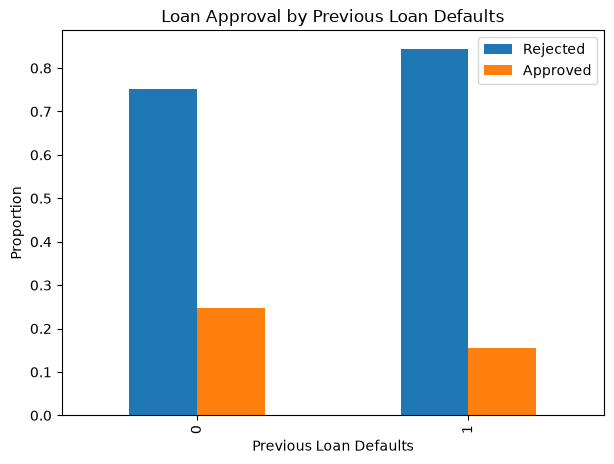

In [186]:
approval_rate.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Loan Approval by Previous Loan Defaults")
plt.ylabel("Proportion")
plt.xlabel("Previous Loan Defaults")

plt.legend(["Rejected", "Approved"])

plt.show()

#### 5. Which employment status recieves  the most approvals?

In [187]:
employment = pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"],
    normalize="index"
)

employment

LoanApproved,0,1
EmploymentStatus,,
Employed,0.759979,0.240021
Self-Employed,0.721551,0.278449
Unemployed,0.818116,0.181884


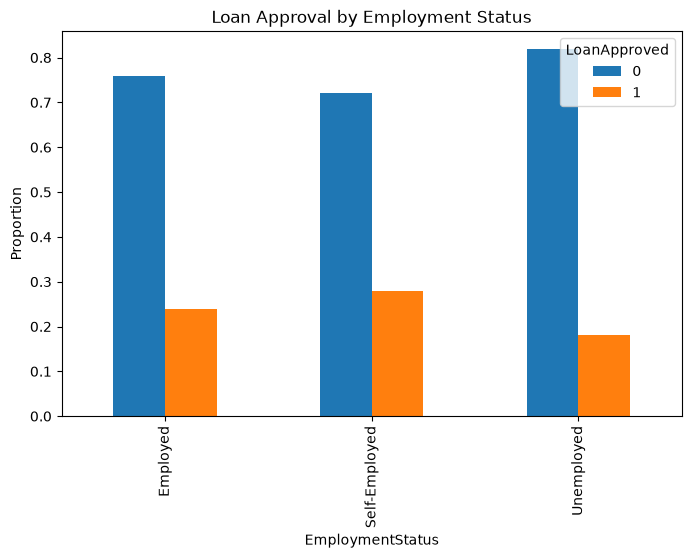

In [188]:
employment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loan Approval by Employment Status")
plt.ylabel("Proportion")

plt.show()

#### 6. Does education level influnce approval?

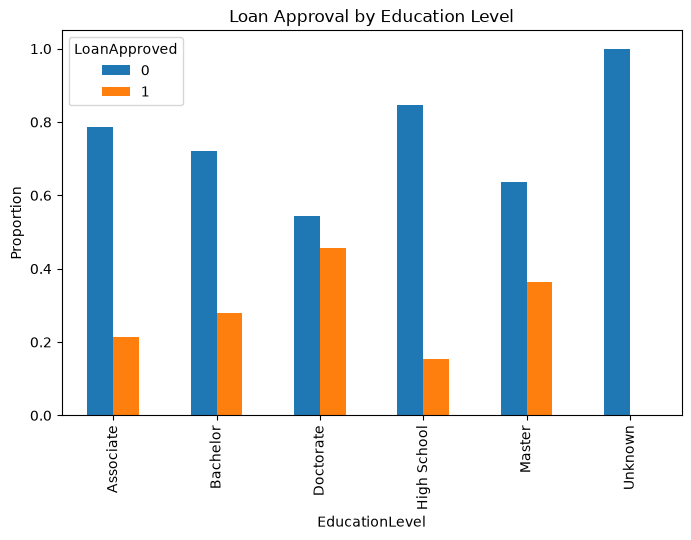

In [189]:
education = pd.crosstab(
    df["EducationLevel"],
    df["LoanApproved"],
    normalize="index"
)

education.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loan Approval by Education Level")
plt.ylabel("Proportion")

plt.show()

### Correlation Analysis

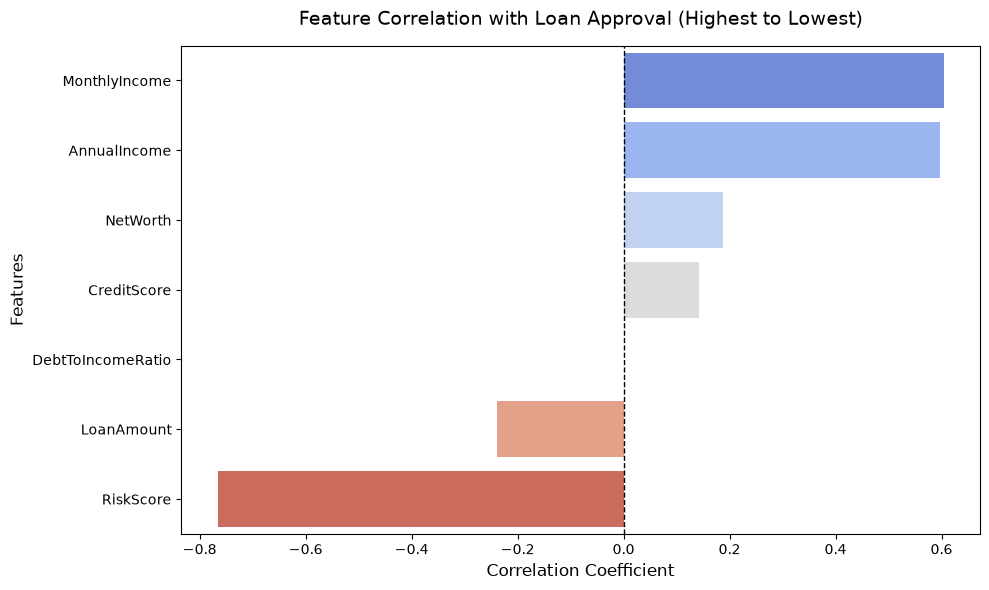

In [190]:
selected_features = [
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "MonthlyIncome",
    "NetWorth",
    "RiskScore",
    "LoanApproved"
]

corr = (df[selected_features]
        .corr()[["LoanApproved"]]
        .drop(index="LoanApproved")
        .sort_values(by="LoanApproved", ascending=False)
    )

plt.figure(figsize=(10, 6))
sns.barplot(
    x= corr['LoanApproved'], 
    y= corr.index, 
    palette='coolwarm'
)

# 4. Add labels and styling
plt.title('Feature Correlation with Loan Approval (Highest to Lowest)', fontsize=14, pad=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Visual guide line at 0
plt.tight_layout()
plt.show()

### Target Leakage Investigation

<Figure size 600x400 with 0 Axes>

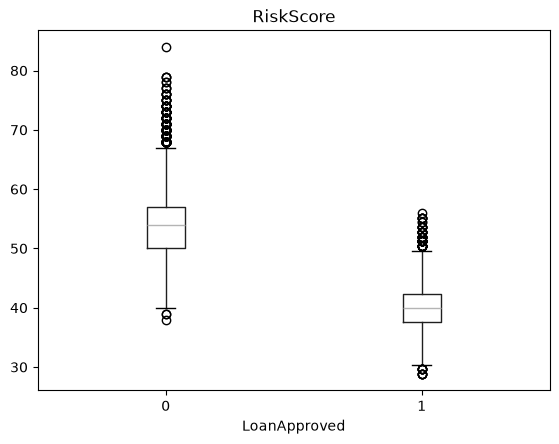

<Figure size 600x400 with 0 Axes>

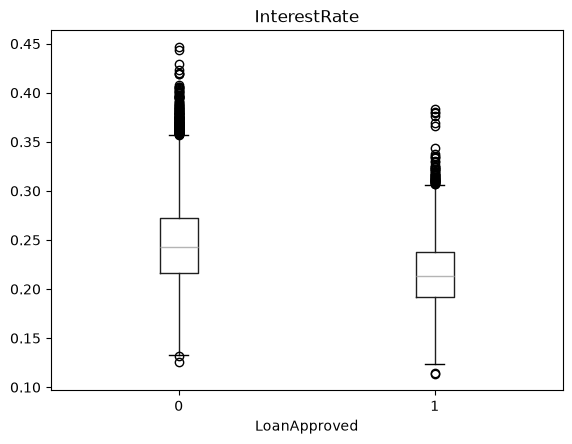

<Figure size 600x400 with 0 Axes>

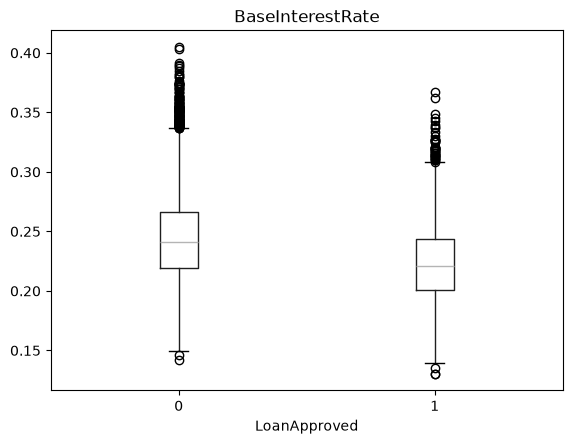

<Figure size 600x400 with 0 Axes>

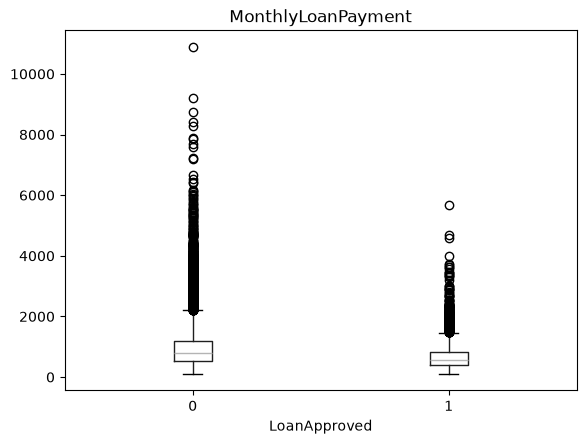

In [191]:
suspect_features = [
    "RiskScore",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment"
]

for col in suspect_features:
    plt.figure(figsize=(6,4))

    df.boxplot(
        column=col,
        by="LoanApproved",
        grid=False
    )

    plt.title(col)
    plt.suptitle("")

    plt.show()

## Key Findings

The exploratory analysis identified several patterns relevant to loan approval:

- Applicants with higher credit scores tended to have higher approval rates.
- Lower debt-to-income ratios were associated with loan approval.
- Employment status influenced approval rates.
- Previous loan defaults reduced the likelihood of approval.
- Several variables, including RiskScore and InterestRate, exhibited very strong relationships with the target and will be evaluated for potential target leakage before model development.

## Feature Engineering and Data Preprocessing

In [192]:
# define X and y 
# features to exclude 
drop_cols = [
    "LoanApproved",
    "RiskScore",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyLoanPayment"
]
y = df["LoanApproved"]
X = df.drop(columns=drop_cols)

# divide data into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Seperate numerical and categorical features 
categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

In [193]:
# Build a preprocessing pipeline 
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Modeling

### Baselines

In [194]:
#  Modeling Code Here - Create New Cells as Needed
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
cv_scores = {}

for name, model in models.items():
    model.fit(X_train_preprocessed, y_train)
    cv_scores[name] = cross_val_score(model, X_train_preprocessed, y_train, cv=5)

# def evaluate_model(model, X_train, X_test, y_train, y_test):


In [195]:
for model, score in cv_scores.items():
    print(f"{model}: {score.mean():.3f}")

Logistic Regression: 0.933
Decision Tree: 0.864
Random Forest: 0.909
AdaBoost: 0.909
Gradient Boosting: 0.924
Support Vector Machine: 0.924
XGBoost: 0.925


In [196]:
lr_model = models["Logistic Regression"].fit(X_train_preprocessed, y_train)
y_pred_lr = lr_model.predict(X_test_preprocessed) 
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)

## Hyperparameter Tuning

### 1. Random Forest

In [197]:
rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_params,
    cv=5,
    scoring="precision",
    n_jobs= -1
)

rf_grid_search.fit(X_train_preprocessed, y_train)
rf_best_model = rf_grid_search.best_estimator_
print("Best Model Results from Grid Search")
print(f"CV Score: {rf_grid_search.best_score_:.3f}")
y_pred_rf = rf_best_model.predict(X_test_preprocessed)
print(f"Classification Report\n{classification_report(y_test, y_pred_rf)}")

Best Model Results from Grid Search
CV Score: 0.787
Classification Report
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      3044
           1       0.80      0.86      0.83       956

    accuracy                           0.92      4000
   macro avg       0.88      0.90      0.89      4000
weighted avg       0.92      0.92      0.92      4000



### 2. Gradient Boosting

In [198]:
gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 0.9, 1.0]
}

gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="precision",
    n_jobs= -1
)

gb_grid_search.fit(X_train_preprocessed, y_train)
gb_best_model = gb_grid_search.best_estimator_
print("Best Model Results from Grid Search")
print(f"CV Score: {gb_grid_search.best_score_:.3f}")
y_pred_gb = gb_best_model.predict(X_test_preprocessed)
print(f"Classification Report\n{classification_report(y_test, y_pred_gb)}")

Best Model Results from Grid Search
CV Score: 0.896
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3044
           1       0.91      0.60      0.72       956

    accuracy                           0.89      4000
   macro avg       0.90      0.79      0.83      4000
weighted avg       0.89      0.89      0.88      4000



### 3. SVM

In [199]:
svm_params = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.1, 0.01],
    "kernel": ["rbf", "linear"]
}

svm_grid_search = GridSearchCV(
    SVC(random_state=42, class_weight="balanced"),
    svm_params,
    cv=5,
    scoring="precision",
    n_jobs= -1
)

svm_grid_search.fit(X_train_preprocessed, y_train)
svm_best_model = svm_grid_search.best_estimator_
print("Best Model Results from Grid Search")
print(f"CV Score: {svm_grid_search.best_score_:.3f}")
y_pred_svm = svm_best_model.predict(X_test_preprocessed)
print(f"Classification Report\n{classification_report(y_test, y_pred_svm)}")

Best Model Results from Grid Search
CV Score: 0.852
Classification Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3044
           1       0.85      0.78      0.81       956

    accuracy                           0.91      4000
   macro avg       0.89      0.87      0.88      4000
weighted avg       0.91      0.91      0.91      4000



### 4. XGBoost

In [200]:
xgb_params = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, class_weight="balanced"),
    xgb_params,
    cv=5,
    scoring="precision",
    n_jobs= -1
)

xgb_grid_search.fit(X_train_preprocessed, y_train)
xgb_best_model = xgb_grid_search.best_estimator_
print("Best Model Results from Grid Search")
print(f"CV Score: {xgb_grid_search.best_score_:.3f}")
y_pred_xgb = xgb_best_model.predict(X_test_preprocessed)
print(f"Classification Report\n{classification_report(y_test, y_pred_xgb)}")

[05:09:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "class_weight" } are not used.



Best Model Results from Grid Search
CV Score: 0.915
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      3044
           1       0.94      0.63      0.75       956

    accuracy                           0.90      4000
   macro avg       0.92      0.81      0.84      4000
weighted avg       0.90      0.90      0.89      4000



### 5. Logistic Regression

In [218]:
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring="precision",
    n_jobs=-1
)

lr_grid_search.fit(X_train_preprocessed, y_train)
lr_best_model = lr_grid_search.best_estimator_
print("Best Model Results from Grid Search")
print(f"CV Score: {lr_grid_search.best_score_:.3f}")
y_pred_lr2 = lr_best_model.predict(X_test_preprocessed)
print(f"Classification Report\n{classification_report(y_test, y_pred_lr2)}")

Best Model Results from Grid Search
CV Score: 0.928
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      3044
           1       0.93      0.61      0.74       956

    accuracy                           0.90      4000
   macro avg       0.91      0.80      0.84      4000
weighted avg       0.90      0.90      0.89      4000



## Evaluation and Conclusion

In [217]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "Xgboost",
        "Logistic Regression Tuned"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr), 2),
        round(accuracy_score(y_test, y_pred_rf), 2),
        round(accuracy_score(y_test, y_pred_gb), 2),
        round(accuracy_score(y_test, y_pred_svm), 2),
        round(accuracy_score(y_test, y_pred_xgb), 2),
        round(accuracy_score(y_test, y_pred_lr2), 2)

    ],
    "Precision": [
        round(precision_score(y_test, y_pred_lr), 2),
        round(precision_score(y_test, y_pred_rf), 2),
        round(precision_score(y_test, y_pred_gb), 2),
        round(precision_score(y_test, y_pred_svm), 2),
        round(precision_score(y_test, y_pred_xgb), 2),
        round(precision_score(y_test, y_pred_lr2), 2)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_lr), 2),
        round(recall_score(y_test, y_pred_rf), 2),
        round(recall_score(y_test, y_pred_gb), 2),
        round(recall_score(y_test, y_pred_svm), 2),
        round(recall_score(y_test, y_pred_xgb), 2),
        round(recall_score(y_test, y_pred_lr2), 2)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred_lr), 2),
        round(f1_score(y_test, y_pred_rf), 2),
        round(f1_score(y_test, y_pred_gb), 2),
        round(f1_score(y_test, y_pred_svm), 2),
        round(f1_score(y_test, y_pred_xgb), 2),
        round(f1_score(y_test, y_pred_lr2), 2)
    ]
    # "ROC AUC": [
    #     roc_auc_score(y_test, y_proba_logreg),
    #     roc_auc_score(y_test, y_proba_rf),
    #     roc_auc_score(y_test, y_proba_gb),
    #     roc_auc_score(y_test, y_proba_svm),
    #     roc_auc,
    #     roc_auc_score(y_test, y_proba_best),
    #     roc_auc_score(y_test, y_prob_ad)
    # ]
})

comparison.sort_values(by="Precision", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,Xgboost,0.90,0.94,0.63,0.75
5,Logistic Regression Tuned,0.90,0.94,0.63,0.75
2,Gradient Boosting,0.89,0.91,0.60,0.72
0,Logistic Regression,0.93,0.88,0.85,0.86
3,SVM,0.91,0.85,0.78,0.81
1,Random Forest,0.92,0.80,0.86,0.83


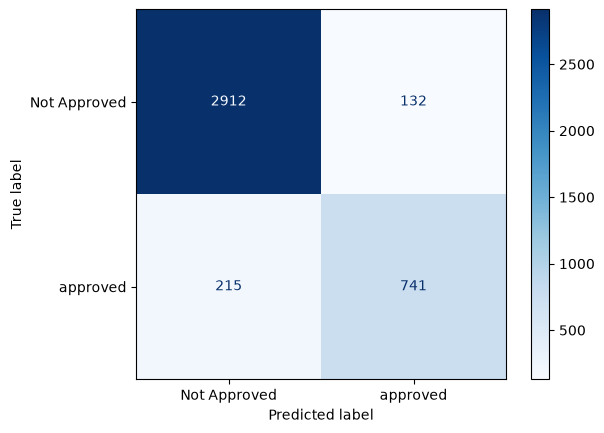

In [202]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Approved", "approved"])
disp.plot(cmap=plt.cm.Blues);

In [209]:
xgb_grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 6,
 'n_estimators': 100,
 'subsample': 0.8}

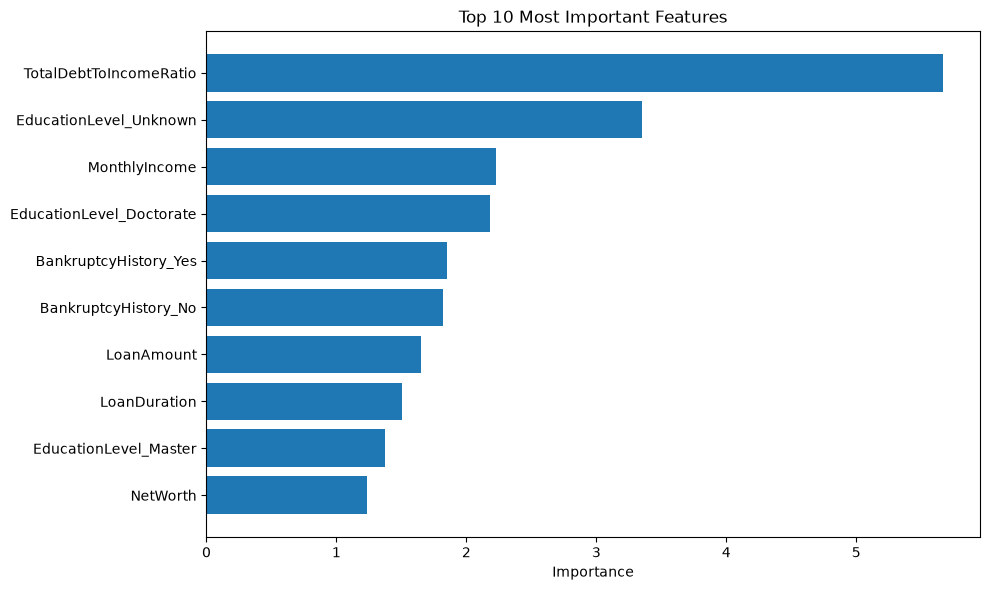

In [212]:
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split("__", 1)[-1] for name in feature_names]

feature_importance = np.abs(lr_model.coef_).ravel()

# Get top 10
top_idx = feature_importance.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(
    [clean_names[i] for i in top_idx],
    feature_importance[top_idx]
)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

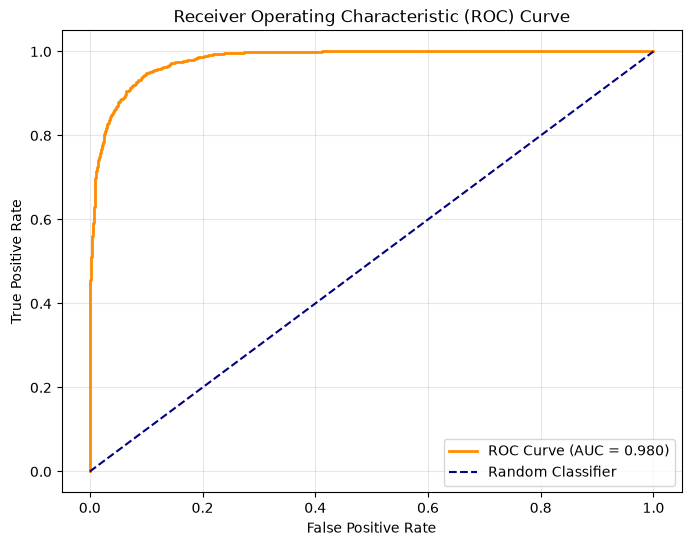

In [214]:
y_pred_proba = lr_model.predict_proba(X_test_preprocessed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr,
         color='darkorange',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='navy',
         label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)
plt.show()

## Model Performance Comparison

Five machine learning algorithms were trained and evaluated to predict loan approval. To provide a comprehensive assessment, each model was compared using **Accuracy, Precision, Recall, and F1-score**.

Since loan approval is a high-stakes financial decision, particular emphasis was placed on **Precision**. In this context, precision measures the proportion of applicants predicted as approved who are actually eligible for approval. A higher precision reduces the likelihood of approving high-risk applicants, thereby helping financial institutions minimize potential loan defaults.

| Model               | Accuracy | Precision |  Recall | F1 Score |
| ------------------- | -------: | --------: | ------: | -------: |
| Logistic Regression |  **93%** |       88% | **85%** |  **86%** |
| XGBoost             |      90% |   **94%** |     63% |      75% |
| Gradient Boosting   |      89% |       91% |     60% |      72% |
| SVM                 |      91% |       85% |     78% |      81% |
| Random Forest       |      92% |       80% |     86% |      83% |

---

# Model Selection

Although **XGBoost** achieved the highest precision (**94%**), it correctly identified only **63%** of the approved applicants. This indicates that the model was conservative, approving fewer applicants in order to minimize false approvals.

**Logistic Regression**, on the other hand, achieved:

* the highest overall accuracy (**93%**),
* the highest F1-score (**86%**),
* strong precision (**88%**),
* and high recall (**85%**).

Rather than excelling in only one metric, Logistic Regression demonstrated the most balanced performance across all evaluation measures.

For this reason, **Logistic Regression was selected as the final model**.

Its performance suggests that it effectively balances identifying qualified applicants while minimizing approvals of applicants who are unlikely to repay their loans.

---

## Why Precision?

Loan approval is fundamentally a **risk management problem**.

Approving an applicant who later defaults can result in financial losses, increased collection costs, and reduced profitability for the lending institution.

Precision directly measures how reliable the model's approval decisions are.

A model with high precision ensures that the majority of applicants predicted as approved are indeed creditworthy, thereby reducing the risk of issuing loans to unsuitable applicants.

Although recall remains an important consideration, particularly when minimizing missed lending opportunities, the financial consequences of approving high-risk applicants justify prioritizing precision for this project.

---

# Feature Importance Analysis

Feature importance was analyzed using the Logistic Regression model to identify the variables that contributed most to loan approval predictions.

The ten most influential features were:

1. **TotalDebtToIncomeRatio**
2. **MonthlyIncome**
3. **LoanDuration**
4. **NetWorth**
5. **AnnualIncome**
6. **EducationLevel (Unknown)**
7. **TotalAssets**
8. **LoanAmount**
9. **BankruptcyHistory**
10. **LengthOfCreditHistory**

### Interpretation

The results indicate that **TotalDebtToIncomeRatio** is by far the most influential predictor of loan approval.

This finding aligns with standard lending practices, as applicants with lower debt obligations relative to their income generally present lower repayment risk. The prominence of this feature suggests that the relationship between existing debt and income is a key determinant of creditworthiness.

Income-related variables, including **MonthlyIncome** and **AnnualIncome**, also ranked among the most important predictors, highlighting the significance of an applicant's earning capacity in the approval process.

Financial strength indicators such as **NetWorth** and **TotalAssets** further emphasize that applicants with stronger financial positions are more likely to receive loan approval.

Loan-specific characteristics, particularly **LoanDuration** and **LoanAmount**, also influenced model decisions. Longer repayment periods or larger loan amounts may alter the perceived lending risk and therefore affect approval outcomes.

Interestingly, the **EducationLevel_Unknown** category appeared among the most influential features. Since this category represents missing education information after one-hot encoding, its importance suggests that incomplete applicant records may contain predictive information within this synthetic dataset. However, this finding should be interpreted cautiously and should not be generalized to real-world lending decisions without further investigation.

Finally, **BankruptcyHistory** and **LengthOfCreditHistory** reinforce the importance of an applicant's historical financial behavior in assessing credit risk.

Overall, the feature importance results are consistent with the variables that financial institutions typically consider during credit evaluation.

---

# Business Recommendations

Based on the findings of this study, the following recommendations are proposed:

**1. Use Logistic Regression as the primary decision-support model.**

The model achieved the best overall balance between accuracy, precision, recall, and F1-score, making it well suited to support consistent and reliable loan approval decisions.

**2. Prioritize debt-to-income ratio during applicant evaluation.**

The analysis identified **TotalDebtToIncomeRatio** as the strongest predictor of loan approval. Applicants with manageable debt relative to their income are generally associated with lower lending risk.

**3. Continue incorporating comprehensive financial information into lending decisions.**

Variables such as monthly income, annual income, total assets, and net worth significantly influenced approval outcomes, demonstrating the importance of evaluating an applicant's overall financial capacity rather than relying on a single metric.

**4. Improve data quality during the application process.**

The predictive importance of the **Unknown** education category suggests that missing applicant information may influence model performance. Financial institutions should encourage complete application submissions to improve both model reliability and fairness.

**5. Use the model as a decision-support system rather than a replacement for human judgment.**

Machine learning models should complement experienced loan officers by providing objective risk assessments while allowing human reviewers to consider exceptional circumstances and regulatory requirements.

**6. Monitor and retrain the model periodically.**

Economic conditions, borrower behavior, and lending policies evolve over time. Regular retraining with new data will help maintain predictive accuracy and ensure the model remains aligned with current lending practices.

---

# Project Conclusion

This project successfully developed an end-to-end machine learning solution for predicting loan approval using demographic, financial, and credit-related applicant information.

The project followed the CRISP-DM framework, beginning with business understanding and progressing through data cleaning, exploratory data analysis, feature engineering, model development, and evaluation.

Five classification algorithms were benchmarked using identical preprocessing pipelines to ensure fair comparison. While XGBoost achieved the highest precision, Logistic Regression demonstrated the strongest overall performance by achieving the highest accuracy and F1-score while maintaining high precision and recall. Its balanced performance makes it the most suitable model for supporting loan approval decisions in this study.

Feature importance analysis highlighted debt-to-income ratio, income measures, net worth, total assets, loan characteristics, and credit history as the primary factors influencing loan approval. These findings closely reflect the financial indicators commonly considered in real-world credit risk assessment.

Overall, this project demonstrates how machine learning can support more consistent, transparent, and data-driven lending decisions. Beyond predictive performance, it emphasizes the importance of thoughtful data preparation, appropriate evaluation metrics, model interpretability, and alignment between business objectives and machine learning outcomes.

---

